In [ ]:
import xarray as xr
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge


from scipy.stats import wasserstein_distance, spearmanr

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
import numpy.ma as ma


from sklearn.utils import resample

import warnings

import seaborn as sns
from astral import moon

from io import BytesIO
from openpyxl.drawing.image import Image
import random

In [2]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
split_year = 2023
split_year_test = 2025
todas = True
test = True
min_time, max_time = pd.to_datetime("2009-01-01"), pd.to_datetime("2025-12-31")

sp = "HKP"

fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

peso = fishing_ds["PesoTotal"]/1000
peso = np.log1p(peso)
peso = peso.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = np.log1p(effort)
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp_ds = temp_ds.rename({"to":"TO"})
temp = temp_ds["TO"]
# temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "TOB"})
temp_bottom = temp_bottom_ds["TOB"]
# temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
# chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed_ds = mixed_ds.rename({"mlotst":"MLOTST"})
mixed = mixed_ds["MLOTST"]
# mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth_ds = depth_ds.rename({"depth":"PROF"})
depth = depth_ds["PROF"]
# depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo_ds = zo_ds.rename({"zo":"ZO"})
zo = zo_ds["ZO"]
# zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so_ds = so_ds.rename({"so":"SO"})
so = so_ds["SO"]
# so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo_ds = ugo_ds.rename({"ugo":"UGO"})
ugo = ugo_ds["UGO"]
# ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo_ds = vgo_ds.rename({"vgo":"VGO"})
vgo = vgo_ds["VGO"]
# vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
# pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
# cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
# spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
# zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "MSEN"
month_cos.name = "MCOS"
month = month.broadcast_like(temp)

times = pd.DatetimeIndex(temp.time.values)

moon_ = np.array([moon.phase(t) for t in times])
moon_phase = xr.DataArray(moon_, coords={"time": temp.time}, dims=["time"], name="FL")
# moon_phase = (moon_phase - moon_phase.mean()) / moon_phase.std()
moon_phase = moon_phase.fillna(0)
moon_phase = moon_phase.broadcast_like(temp)


year = temp["time"].dt.year
# year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)
year.name = "Año"

lat = temp["lat"]
lon = temp["lon"]
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)
lat.name = "LAT"
lon.name = "LON"

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd, moon_phase = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, moon_phase, join="inner")

fishing, peso, effort, mask = xr.align(fishing, peso, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)
peso = croppedT(peso)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)
moon_phase = cropped(moon_phase)

(204, 19, 62, 25)


,feature,VIF
2,ZO,22.085384
9,PP,21.307090
18,PROF,19.018034
0,TO,13.240718
8,CHL,10.556771
3,TOB,8.154096
1,SO,8.098905
13,MCOS,5.814280
12,MSEN,5.471679
10,ZSD,5.181091


Suggested variables to drop: ['TOB', 'PP', 'PROF']


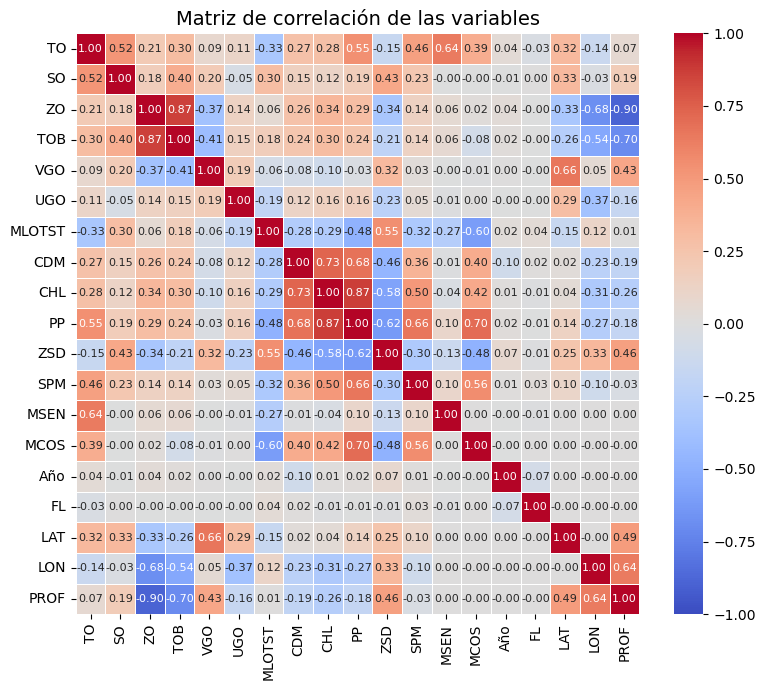

Train shape: torch.Size([156, 12, 19, 62, 25])
Val shape: torch.Size([24, 12, 19, 62, 25])
Test shape: torch.Size([12, 12, 19, 62, 25])
Test Y shape: torch.Size([12, 30, 17])


In [3]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")

vars_ = [temp,
        ugo, vgo, mixed,
        cdm, chl, spm,
        month_sin, month_cos,
        ]

if todas:
    vars_ = [temp, 
        so,  zo, temp_bottom,
        ugo, vgo, mixed,
        cdm, chl,  pp, zsd, spm,
        month_sin, month_cos,
        year,
        moon_phase,
        lat, lon,
        depth,
        ]


vars_names = [v.name for v in vars_]
in_channels = len(vars_)

X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")

print(X.shape)




# -------- Data Standardization (Z-score Normalization) --------
X = X.assign_coords(channel=vars_names)
epsilon = 1e-8 

# 1. Isolate the training period ONLY to calculate mean/std (prevents data leakage)
train_slice = X.sel(time=slice(None, f"{split_year-1}-12-31"))
train_mean = train_slice.mean(dim=["time", "lat", "lon"], skipna=True)
train_std  = train_slice.std(dim=["time", "lat", "lon"], skipna=True)

# 2. Set mean=0 and std=1 for features that do not require standarization

for feat in ["MSEN", "MCOS"]:
    if feat in train_mean.coords["channel"].values:
        train_mean.loc[dict(channel=feat)] = 0.0
        train_std.loc[dict(channel=feat)] = 1.0 - epsilon

# 3. Apply the transformation to the ENTIRE dataset
X_scaled = (X - train_mean) / (train_std + epsilon)


# -------- Check correlations --------
X_np = X_scaled.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
#inflation factor
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
display((vif_data.sort_values("VIF", ascending=False)))

#correlation matrix
corr_matrix = df.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.75)]
print(f"Suggested variables to drop: {to_drop}")
plt.figure(figsize=(8, 7))
if todas:
    sns.heatmap(corr_matrix, annot=True,cmap="coolwarm", fmt=".2f",vmin=-1,vmax=1, linewidths=0.5, annot_kws={"size": 8})
else: 
    sns.heatmap(corr_matrix, annot=True,cmap="coolwarm", fmt=".2f",vmin=-1,vmax=1, linewidths=0.5)

plt.title("Matriz de correlación de las variables", fontsize=14)
plt.tight_layout()
plt.show()



# -------- Window Creation --------
# We modify this slightly to also return the exact timestamp of the target (y)
def create_windows_full(X_ds, y_ds, m_ds, window=12):
    X_data = X_ds.values   # (time, channels, H, W)
    y_data = y_ds.values   # (time, H, W)
    m_data = m_ds.values   # (time, H, W)
    time_data = y_ds.time.values # Track the timestamps
    
    X_seq, y_seq, m_seq, time_seq = [], [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) # 12 months history
        y_seq.append(y_data[i+window])   # 1 month target
        m_seq.append(m_data[i+window])   # 1 month mask target
        time_seq.append(time_data[i+window]) # The timestamp of the target
        
    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
        pd.to_datetime(time_seq) # Convert to pandas datetime for easy filtering
    )

window = 12

# 4. Create windows over the entire scaled dataset
X_all, y_all, m_all, t_all = create_windows_full(X_scaled, y, m, window)


# -------- Split into Train/Val/Test --------
# 5. Split the tensors based on the target's year
train_mask = t_all.year < split_year
val_mask = (t_all.year >= split_year) & (t_all.year < split_year_test)
test_mask = t_all.year >= split_year_test

X_train, y_train, m_train = X_all[train_mask], y_all[train_mask], m_all[train_mask]
X_val, y_val, m_val = X_all[val_mask], y_all[val_mask], m_all[val_mask]
X_test, y_test, m_test = X_all[test_mask], y_all[test_mask], m_all[test_mask]

print("Train shape:", X_train.shape)  # Will be N - 12
print("Val shape:", X_val.shape)      
print("Test shape:", X_test.shape)    
print("Test Y shape:", y_test.shape)

###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val, m_val),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)




In [4]:
def prep_ml_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays 
    compatible with scikit-learn Random Forest. Handles both Torch tensors and Numpy arrays.
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    # For your train data: (72, 12, 11, 94, 48) -> (72, 595584)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    # For your train data: (72, 37, 20) -> (72, 740)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_ml_data(X_train, y_train, m_train)
X_val_ml, y_val_ml, m_val_ml = prep_ml_data(X_val, y_val, m_val)
X_test_ml, y_test_ml, m_test_ml = prep_ml_data(X_test, y_test, m_test)



H_val_test, W_val_test = y_val.shape[1], y_val.shape[2]
H_out_test, W_out_test = y_test.shape[1], y_test.shape[2]

m_true_val = m_val_ml.reshape(-1, H_val_test, W_val_test)
y_true_val = y_val_ml.reshape(-1, H_val_test, W_val_test)

m_true = m_test_ml.reshape(-1, H_out_test, W_out_test)
y_true = y_test_ml.reshape(-1, H_out_test, W_out_test)

mask_flat = m_test_ml.astype(bool)


In [5]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_test_flat = y_test_ml.flatten()
    y_pred_flat = y_pred_flat.flatten()
    
    mask_spatial = mask_spatial.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)
    

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    # print("RMSE:", f"{rmse:.4f}")
    # print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    # print("MAE:", f"{mae:.4f}")
    # print("R2:", f"{r2:.4f}")
    # print("Pearson R:", f"{pearson_corr:.4f}")
    # print("MBE:", f"{mbe:.4f}")
    # print(f"Wasserstein Distance: {w_dist:.4f}")
    # print(f"Spearman Rank Correlation: {spearman_corr:.2f}")

    # =====================================================
    # HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    # Create boolean masks for the top 20%
    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    # Count how many points are in the true top 20%
    total_actual_hotspots = np.sum(actual_hotspots)

    # Count how many points are in BOTH the true top 20% AND predicted top 20%
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)

    # Calculate the Hit Rate percentage
    hit_rate = shared_hotspots / total_actual_hotspots
    hit_rate_percent = hit_rate * 100

    # print(f"\n--- Total hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    # print(f"Hit Rate                        : {hit_rate_percent:.4f}%")

    # =====================================================
    # MONTHLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    # Iterate through each month (time step)
    for i in range(y_true.shape[0]):
        
        # Handle the spatial mask safely (whether it is 2D or 3D)
        current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
        
        # Extract valid pixels strictly for this month
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred3D_temp[i][current_mask]
        
        # Skip if mask leaves no valid pixels for this month
        if len(y_true_month) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific month
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        # Count overlaps
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        # Calculate hit rate strictly for this month
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    mean_monthly_hit_rate = np.mean(monthly_hit_rates)
    # print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")



    # =====================================================
    # YEARLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80

    yearly_hit_rates = []

    # Iterate through time in 12-month chunks
    for year_idx in range(0, y_true.shape[0], 12):
        end_idx = min(year_idx + 12, y_true.shape[0])

        if mask_spatial.ndim == 3:
            current_mask = mask_spatial[year_idx:end_idx].astype(bool)

            y_true_year = y_true[year_idx:end_idx][current_mask]
            y_pred_year = y_pred3D_temp[year_idx:end_idx][current_mask]

        else:
            current_mask = mask_spatial.astype(bool)

            y_true_year = y_true[year_idx:end_idx][:, current_mask].flatten()
            y_pred_year = y_pred3D_temp[year_idx:end_idx][:, current_mask].flatten()

        # Skip empty years
        if len(y_true_year) == 0:
            continue

        # Year-specific top 20% thresholds
        thresh_true_year = np.percentile(y_true_year, percentile)
        thresh_pred_year = np.percentile(y_pred_year, percentile)

        actual_hotspots_year = y_true_year >= thresh_true_year
        pred_hotspots_year = y_pred_year >= thresh_pred_year

        total_actual_year = np.sum(actual_hotspots_year)
        shared_year = np.sum(actual_hotspots_year & pred_hotspots_year)

        if total_actual_year > 0:
            yearly_hit_rates.append((shared_year / total_actual_year) * 100)

    mean_yearly_hit_rate = np.mean(yearly_hit_rates) if yearly_hit_rates else 0
    # print(f"Mean Yearly Hit Rate                : {mean_yearly_hit_rate:.3f}%")
    # print(f"-------------------------------------------------\n")

    # =====================================================
    # Reshape to 3D
    # =====================================================
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D = y_pred_flat.reshape(-1, H_out, W_out)
    mask_spatial = mask_spatial.astype(bool)

    # =====================================================
    # SSIM
    # =====================================================
    data_range = (y_true[mask_spatial].max()-y_true[mask_spatial].min())

    ssim_scores = []

    for i in range(y_true.shape[0]):

        _, ssim_map = ssim(
            y_true[i],
            y_pred3D[i],
            data_range=data_range,
            win_size=5,
            full=True
        )

        valid_ssim_pixels = ssim_map[mask_spatial[i]]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)

    # print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # PLOTTING
    # =====================================================

    y_true_m = np.where(mask_spatial, y_true, 0)
    y_pred_m = np.where(mask_spatial, y_pred3D, 0)

    # 2. Compute means. The masked array automatically ignores the hidden values!
    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
 
    error = y_pred_mean - y_true_mean

    # plt.figure(figsize=(12, 4))

    # ax1 = plt.subplot(1, 3, 1)
    # plt.title("Mean Test Truth")
    # plt.imshow(y_true_mean, cmap='viridis') 
    # plt.colorbar()
    # ax1.invert_yaxis()

    # ax2 = plt.subplot(1, 3, 2)
    # plt.title("Mean Test Prediction")
    # plt.imshow(y_pred_mean, cmap='viridis')
    # plt.colorbar()
    # ax2.invert_yaxis()

    # ax3 = plt.subplot(1, 3, 3)
    # plt.title("Mean Error (Pred - True)")
    
    # plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    # plt.colorbar()
    # ax3.invert_yaxis()

    # plt.tight_layout()
    # plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_true_m2 = ma.masked_where(~mask_spatial, y_true)
    y_pred_m2 = ma.masked_where(~mask_spatial, y_pred3D)
    y_pred_plot2 = y_pred_m2.mean(axis=(1, 2))
    y_true_plot2 = y_true_m2.mean(axis=(1, 2))
    
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    # fig, ax = plt.subplots(figsize=(12, 4))

    # ax.plot(y_true_plot2, label="Real")
    # ax.plot(y_pred_plot2, label="Predicho")
    # ax.set_ylabel("Valor Promedio")
    
    # ax.annotate(f"R2: {r2_plot2:.3f}",xy=(0.98, 0.02),xycoords="axes fraction",ha="right",va="bottom",)
    # ax.set_xlabel("Tiempo (Meses)")
    # ax.legend()

    # plt.show()
    
    metrics = [r2, pearson_corr, r2_plot2, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr, hit_rate_percent, mean_yearly_hit_rate, mean_monthly_hit_rate]
    
    return metrics

In [6]:
iters = 10
columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
metrics_df = pd.DataFrame(columns=columns)
importance_all_df = pd.DataFrame(columns=vars_names)

for i in range(iters):
    model = RandomForestRegressor(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=random.randint(0, 1000))

    model.fit(X_train_ml, y_train_ml)

    y_pred_flat = model.predict(X_test_ml)

    # compute R2 on validation set only for saving it
    y_pred_val_flat = model.predict(X_val_ml)
    y_pred_val_flat = y_pred_val_flat.flatten()
    y_val_flat = y_val_ml.flatten()

    mask_spatial = m_true_val.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)

    y_val_flat_masked = y_val_flat[mask_flat]
    y_pred_val_flat_masked = y_pred_val_flat[mask_flat]

    val_r2 = r2_score(y_val_flat_masked, y_pred_val_flat_masked)
    #-------------------------------------------------------------------------------
    metrics = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
    metrics_df.loc[len(metrics_df)] = metrics


    # -------- Feature Importance Extraction --------
    raw_importances = model.feature_importances_
    T = X_train.shape[1]   # window (12)
    C = X_train.shape[2]   # number of variables/channels
    H_x = X_train.shape[3] # height (lat)
    W_x = X_train.shape[4] # width (lon)

    reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)

    variable_importances = reshaped_importances.sum(axis=(0, 2, 3))


    importance_all_df.loc[len(importance_all_df)] = variable_importances


importance_summary_df = pd.DataFrame({"Variable": vars_names, 
                                      "Importance": [f"{importance_all_df[var].mean():.3f}±{importance_all_df[var].std():.3f}"for var in vars_names],
                                      "Mean Importance": [importance_all_df[var].mean()for var in vars_names]})

# Sort by mean importance
importance_summary_df = importance_summary_df.sort_values(by="Mean Importance",ascending=False).reset_index(drop=True)

# Optional: remove helper column before saving
importance_summary_df = importance_summary_df.drop(columns=["Mean Importance"])

metrics_summary_df = pd.DataFrame(
{col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_todas"

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    importance_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_summary_df) + 3, index=False)


In [7]:
metrics_summary_df


,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.541±0.004,0.761±0.002,0.596±0.014,0.520±0.003,1.858±0.008,0.190±0.001,1.292±0.008,-0.459±0.012,1.010±0.008,0.720±0.002,48.767±0.771,48.767±0.771,34.233±0.828


In [8]:
iters = 10
columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
metrics_df = pd.DataFrame(columns=columns)
importance_all_df = pd.DataFrame(columns=vars_names)

for i in range(iters):
    model = ExtraTreesRegressor(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=random.randint(0, 1000))

    model.fit(X_train_ml, y_train_ml)

    y_pred_flat = model.predict(X_test_ml)
    #-------------------------------------------------------------------------------
    metrics = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
    metrics_df.loc[len(metrics_df)] = metrics


metrics_summary_df = pd.DataFrame(
{col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_todas"

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)


In [9]:
columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
metrics_df = pd.DataFrame(columns=columns)

model = KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

#-------------------------------------------------------------------------------
metrics= compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
metrics_df.loc[len(metrics_df)] = metrics


# save everyhtng to a excel workbook
model_name = model.__class__.__name__
sheet_name = f"{model_name}_{sp}"
if not todas:
    with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

    with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
        ws = writer.sheets[sheet_name]



c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [10]:
iters = 10
columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
metrics_df = pd.DataFrame(columns=columns)
importance_all_df = pd.DataFrame(columns=vars_names)
alpha = 100
solver = "svd"
for i in range(iters):
    ridge_model = Ridge(alpha=alpha, solver=solver, random_state=random.randint(0, 1000))
    ridge_model.fit(X_train_ml, y_train_ml)

    y_pred_flat = model.predict(X_test_ml)

    #-------------------------------------------------------------------------------
    metrics = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
    metrics_df.loc[len(metrics_df)] = metrics



metrics_summary_df = pd.DataFrame(
{col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

# -------- Bootstrapping for Statistical metrics --------
# warnings.filterwarnings("ignore", message="Singular matrix in solving dual problem") # Suppress the specific warning 

n_iterations = 50  
n_features = X_train_ml.shape[1]
bootstrapped_coefs = np.zeros((n_iterations, n_features), dtype=np.float32)

print(f"Running {n_iterations} bootstrap iterations")

for i in range(n_iterations):
    X_boot, y_boot = resample(X_train_ml, y_train_ml, random_state=i)
    boot_model = Ridge(alpha=alpha, solver=solver, random_state=i)
    boot_model.fit(X_boot, y_boot)
    bootstrapped_coefs[i, :] = boot_model.coef_.mean(axis=0)

# -------- Advanced Statistical Feature Extraction (Confidence Intervals) --------

# Calculate the 2.5th and 97.5th percentiles to build a 95% Confidence Interval
# This acts as our mathematical surrogate for a two-tailed p < 0.05 threshold
lower_bound = np.percentile(bootstrapped_coefs, 2.5, axis=0)
upper_bound = np.percentile(bootstrapped_coefs, 97.5, axis=0)

# A feature is statistically stable/significant if its 95% CI does not cross zero
# (meaning it is strictly positive or strictly negative across 95% of resamples)
is_significant = (lower_bound > 0) | (upper_bound < 0)

# -------- Reshaping & Grid Aggregation --------

# Extract and average coefficients from your baseline full-dataset model
raw_ridge_coefs = ridge_model.coef_.mean(axis=0)

# Reshape both baseline weights and the significance mask back to the 5D spatiotemporal grid
reshaped_ridge_coefs = raw_ridge_coefs.reshape(T, C, H_x, W_x)
reshaped_significance = is_significant.reshape(T, C, H_x, W_x)

# Calculate final aggregated metrics across dimensions (T, H_x, W_x)
# Significant_Grid_Ratio: % of the spatiotemporal domain where the variable is significant
significant_grid_ratio = reshaped_significance.mean(axis=(0, 2, 3))
global_ridge_weights = np.abs(reshaped_ridge_coefs).mean(axis=(0, 2, 3))*10000
global_ridge_direction = np.sign(reshaped_ridge_coefs.mean(axis=(0, 2, 3)))

direction_labels = ['Positiva (+)' if d > 0 else 'Negativa (-)' for d in global_ridge_direction]

# Compile the final statistical report
ridge_importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Overall_Impact': global_ridge_weights,
    'Direction': direction_labels,
    'Significant_Grid_Ratio': significant_grid_ratio
})
ridge_importance_df = ridge_importance_df.sort_values(by='Overall_Impact', ascending=False)
print("\n--- Ridge (L2) Bootstrapped Significance Report ---")
display(ridge_importance_df)

coefs_by_month = np.abs(reshaped_ridge_coefs).mean(axis=(2, 3))*10000
significance_by_month = reshaped_significance.mean(axis=(2, 3))
direction_by_month = np.sign(reshaped_ridge_coefs.mean(axis=(2, 3)))
direction_labels_by_month = np.where(direction_by_month > 0, '(+)', '(-)')

print("\n--- Overall Importance monthly ---")
ridge_importance_df_monthly = pd.DataFrame(coefs_by_month, columns=vars_names)
ridge_importance_df_monthly.index = [f"Month_lag_{i+1}" for i in range(T)]
display(ridge_importance_df_monthly)

print("\n--- Overall direction monthly ---")
ridge_significance_df_monthly = pd.DataFrame(significance_by_month, columns=vars_names)
ridge_significance_df_monthly.index = [f"Month_lag_{i+1}" for i in range(T)]

ridge_direction_df_monthly = pd.DataFrame(direction_labels_by_month, columns=vars_names)
ridge_direction_df_monthly.index = [f"Month_lag_{i+1}" for i in range(T)]
ridge_direction_with_sig_df_monthly = (ridge_direction_df_monthly.astype(str)+ " " + ridge_significance_df_monthly.round(3).astype(str))
display(ridge_direction_with_sig_df_monthly)

# save everyhtng to a excel workbook
model_name = ridge_model.__class__.__name__
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_ALL"
with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    ridge_importance_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_summary_df) + 3, index=False)
    ws = writer.sheets[sheet_name]

Running 50 bootstrap iterations

--- Ridge (L2) Bootstrapped Significance Report ---


,Variable,Overall_Impact,Direction,Significant_Grid_Ratio
11,SPM,1.522278e-01,Negativa (-),0.154624
7,CDM,1.380685e-01,Negativa (-),0.215376
6,MLOTST,1.253336e-01,Negativa (-),0.278871
10,ZSD,1.246608e-01,Positiva (+),0.181129
8,CHL,1.217376e-01,Negativa (-),0.178817
9,PP,9.494458e-02,Negativa (-),0.198172
5,UGO,8.851734e-02,Negativa (-),0.125699
4,VGO,6.308502e-02,Negativa (-),0.104892
15,FL,4.497684e-02,Positiva (+),0.000000
0,TO,4.405105e-02,Positiva (+),0.225591



--- Overall Importance monthly ---


,TO,SO,ZO,TOB,VGO,UGO,MLOTST,CDM,CHL,PP,ZSD,SPM,MSEN,MCOS,Año,FL,LAT,LON,PROF
Month_lag_1,0.050848,0.001698,0.027525,0.026592,0.046003,0.079164,0.104107,0.142232,0.148689,0.099926,0.107892,0.140624,0.023470,0.031943,0.056196,0.028705,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_2,0.031586,0.003820,0.027899,0.037341,0.057720,0.089244,0.085617,0.170727,0.115798,0.113425,0.179908,0.160884,0.036297,0.015928,0.010472,0.013179,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_3,0.051291,0.002095,0.019537,0.025993,0.055212,0.083474,0.103670,0.138903,0.129723,0.085534,0.114681,0.171358,0.039399,0.004354,0.015810,0.086448,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_4,0.026699,0.004595,0.048395,0.040566,0.065193,0.097906,0.121305,0.118309,0.118405,0.088151,0.159059,0.162553,0.031943,0.023470,0.037560,0.015405,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_5,0.032425,0.001509,0.040476,0.026186,0.069405,0.084506,0.096895,0.135225,0.126592,0.068254,0.087604,0.122726,0.015928,0.036297,0.024980,0.052116,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_6,0.040246,0.002470,0.071450,0.042599,0.062357,0.098080,0.094186,0.179404,0.120981,0.088355,0.144368,0.112160,0.004354,0.039399,0.028369,0.027867,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_7,0.052183,0.004016,0.042506,0.026398,0.071597,0.113470,0.155239,0.123070,0.119619,0.117303,0.107616,0.100838,0.023470,0.031943,0.037316,0.067714,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_8,0.033776,0.006882,0.043532,0.028417,0.069307,0.080856,0.229754,0.128064,0.126852,0.090025,0.104022,0.150744,0.036297,0.015928,0.043310,0.058809,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_9,0.049979,0.004417,0.022404,0.020138,0.060604,0.073934,0.166267,0.143971,0.113491,0.101978,0.100765,0.115795,0.039399,0.004354,0.022725,0.017720,1.592098e-11,1.795160e-11,1.507164e-11
Month_lag_10,0.042181,0.005672,0.026236,0.042558,0.076981,0.093271,0.152944,0.114422,0.113595,0.099941,0.170598,0.199564,0.031943,0.023470,0.026848,0.000013,1.592098e-11,1.795160e-11,1.507164e-11



--- Overall direction monthly ---


,TO,SO,ZO,TOB,VGO,UGO,MLOTST,CDM,CHL,PP,ZSD,SPM,MSEN,MCOS,Año,FL,LAT,LON,PROF
Month_lag_1,(-) 0.043,(-) 0.032,(-) 0.002,(-) 0.275,(+) 0.061,(-) 0.096,(+) 0.214,(-) 0.08,(+) 0.18,(+) 0.204,(-) 0.084,(-) 0.137,(-) 1.0,(-) 1.0,(+) 1.0,(+) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_2,(-) 0.463,(-) 0.394,(+) 0.072,(+) 0.398,(+) 0.098,(-) 0.163,(+) 0.138,(+) 0.275,(+) 0.18,(-) 0.219,(-) 0.203,(-) 0.152,(-) 1.0,(-) 1.0,(+) 1.0,(-) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_3,(-) 0.341,(+) 0.017,(-) 0.01,(+) 0.31,(+) 0.079,(-) 0.146,(+) 0.147,(-) 0.19,(+) 0.23,(-) 0.186,(+) 0.156,(+) 0.223,(-) 1.0,(+) 0.0,(+) 1.0,(+) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_4,(-) 0.046,(-) 0.449,(+) 0.243,(+) 0.514,(+) 0.094,(-) 0.181,(+) 0.171,(-) 0.149,(-) 0.209,(-) 0.167,(+) 0.244,(-) 0.157,(-) 1.0,(+) 1.0,(+) 1.0,(-) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_5,(-) 0.077,(+) 0.002,(+) 0.02,(-) 0.317,(+) 0.192,(-) 0.099,(+) 0.061,(-) 0.293,(-) 0.243,(-) 0.128,(+) 0.099,(+) 0.053,(-) 1.0,(+) 1.0,(+) 1.0,(-) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_6,(+) 0.054,(-) 0.029,(+) 0.315,(+) 0.59,(-) 0.114,(+) 0.119,(+) 0.135,(-) 0.514,(-) 0.154,(+) 0.168,(+) 0.245,(-) 0.031,(+) 0.0,(+) 1.0,(+) 1.0,(+) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_7,(+) 0.624,(-) 0.199,(+) 0.274,(-) 0.308,(-) 0.109,(+) 0.157,(-) 0.416,(+) 0.042,(-) 0.055,(+) 0.224,(+) 0.135,(+) 0.041,(+) 1.0,(+) 1.0,(+) 1.0,(+) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_8,(+) 0.04,(-) 0.223,(+) 0.119,(-) 0.247,(-) 0.154,(+) 0.1,(-) 0.721,(-) 0.14,(+) 0.135,(-) 0.145,(+) 0.102,(-) 0.054,(+) 1.0,(+) 1.0,(+) 1.0,(-) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_9,(-) 0.075,(-) 0.319,(-) 0.012,(+) 0.168,(-) 0.069,(+) 0.068,(-) 0.46,(+) 0.239,(-) 0.187,(-) 0.203,(+) 0.147,(+) 0.075,(+) 1.0,(-) 0.0,(+) 1.0,(+) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
Month_lag_10,(-) 0.134,(-) 0.252,(-) 0.0,(+) 0.454,(+) 0.126,(+) 0.128,(-) 0.446,(-) 0.142,(-) 0.255,(-) 0.308,(+) 0.453,(-) 0.335,(+) 1.0,(-) 1.0,(+) 1.0,(-) 0.0,(-) 0.0,(+) 0.0,(-) 0.0
